# Implementação de uma Rede Direta MLP com Aprendizado Supervisionado

**Disciplina:** Inteligência Computacional / Machine Learning — CESUPA

**Professora:** Polyana Santos Fonseca Nascimento

**Integrantes:** Rafael Batista Ferreira e Paulo Ricardo da Rocha Cunha

**Dataset:** Air Quality UCI (UCI Machine Learning Repository)


## 1. Escolha e validação do Dataset

**Dataset:** [Air Quality Data Set — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/360/air+quality)

**Tipo de problema:** Regressão.

**Descrição:** o dataset contém medições horárias de um equipamento multissensor de baixo custo (array de 5 sensores de óxido de metal) instalado em uma área urbana poluída na Itália, entre março de 2004 e fevereiro de 2005, junto com as concentrações de referência medidas por um analisador certificado.

**Variável-alvo:** `C6H6(GT)` — concentração de benzeno de referência, em µg/m³ (medida pelo analisador certificado, não pelo sensor de baixo custo). Trata-se de um problema real de calibração de sensores: prever a leitura do equipamento de referência (caro) a partir das leituras dos sensores de baixo custo e de variáveis ambientais.

**Número de instâncias (antes da limpeza):** 9.357 (excluindo linhas totalmente vazias no fim do arquivo).

**Número de atributos (antes da limpeza):** 15 (incluindo Data e Hora), sendo 12 atributos numéricos além da variável-alvo.

**Natureza e faixa de valores da variável-alvo:** variável contínua, concentração de benzeno em µg/m³, variando de aproximadamente 0 a 63,7 µg/m³ nas leituras válidas (valores ausentes são codificados como -200 no dataset original e serão tratados na etapa de pré-processamento).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from scipy.stats import loguniform

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 2. Pré-processamento e Análise dos Dados

### 2.1. Carregamento e limpeza inicial

O arquivo usa `;` como separador de colunas e `,` como separador decimal (padrão europeu). As duas últimas colunas (`Unnamed: 15`, `Unnamed: 16`) são completamente vazias (artefato da exportação do CSV original) e são descartadas, assim como as linhas totalmente vazias ao final do arquivo.

Os valores ausentes no dataset original são codificados como **-200**, e não como `NaN`. Isso precisa ser tratado explicitamente.


In [2]:
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
print('Shape bruto:', df.shape)
df.head()


Shape bruto: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [3]:
# Remove colunas totalmente vazias e linhas totalmente vazias
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df = df.dropna(how='all', subset=['Date'])
print('Shape apos remover linhas/colunas vazias:', df.shape)

# Contagem de valores ausentes (-200) por coluna
missing_counts = (df.iloc[:, 2:] == -200).sum().sort_values(ascending=False)
print('\nValores ausentes (-200) por coluna:')
print(missing_counts)


Shape apos remover linhas/colunas vazias: (9357, 15)

Valores ausentes (-200) por coluna:
NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S1(CO)       366
PT08.S2(NMHC)     366
C6H6(GT)          366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


### 2.2. Tratamento de valores ausentes

- `NMHC(GT)` tem ~90% de valores ausentes (o sensor de referência para hidrocarbonetos não-metânicos falhou na maior parte do período). Como não é viável imputar de forma confiável uma coluna com 90% de dados faltantes, **a coluna é descartada**.
- A variável-alvo `C6H6(GT)` tem 366 valores ausentes, que correspondem a instantes em que **todo o equipamento sensor** ficou fora do ar (as mesmas 366 linhas têm -200 em todos os sensores `PT08.*`). Como não é possível treinar/avaliar supervisionadamente sem o rótulo, **essas linhas são descartadas**.
- Após remover essas linhas, os sensores `PT08.*`, `T`, `RH` e `AH` ficam sem valores ausentes (eram os mesmos instantes de falha do equipamento).
- `CO(GT)`, `NOx(GT)` e `NO2(GT)` são leituras do **analisador de referência** (não do equipamento de baixo custo) e ainda apresentam valores ausentes independentes (o analisador de referência falhou em outros instantes). Esses são **imputados pela mediana** da própria coluna, por ser uma medida robusta a outliers e por essas variáveis não serem extremamente enviesadas.


In [4]:
df = df.drop(columns=['NMHC(GT)'])
df = df[df['C6H6(GT)'] != -200].copy()
print('Shape apos remover linhas com alvo ausente:', df.shape)

for c in ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
          'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']:
    n_missing = (df[c] == -200).sum()
    if n_missing:
        print(f'{c}: {n_missing} valores -200 substituidos pela mediana')
        df[c] = df[c].replace(-200, np.nan)
        df[c] = df[c].fillna(df[c].median())

print('\nValores ausentes restantes:', (df.iloc[:, 2:] == -200).sum().sum())


Shape apos remover linhas com alvo ausente: (8991, 14)
CO(GT): 1647 valores -200 substituidos pela mediana
NOx(GT): 1595 valores -200 substituidos pela mediana
NO2(GT): 1598 valores -200 substituidos pela mediana

Valores ausentes restantes: 0


### 2.3. Engenharia de atributos a partir de Data/Hora

Poluentes atmosféricos têm forte padrão sazonal e diário (tráfego, temperatura, etc.). As colunas `Date` e `Time` são combinadas e decompostas em `hour`, `month` e `dayofweek`, que carregam essa informação de forma numérica utilizável pelo modelo; as colunas textuais originais são descartadas.


In [5]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df['hour'] = df['DateTime'].dt.hour
df['month'] = df['DateTime'].dt.month
df['dayofweek'] = df['DateTime'].dt.dayofweek
df = df.drop(columns=['Date', 'Time', 'DateTime'])
df = df.reset_index(drop=True)
df.head()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,month,dayofweek
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,3,2
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,3,2
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,3,2
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,3,2
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,3,2


### 2.4. Análise da variável-alvo (distribuição, escala, dispersão, outliers)


count    8991.000000
mean       10.083105
std         7.449820
min         0.100000
25%         4.400000
50%         8.200000
75%        14.000000
max        63.700000
Name: C6H6(GT), dtype: float64


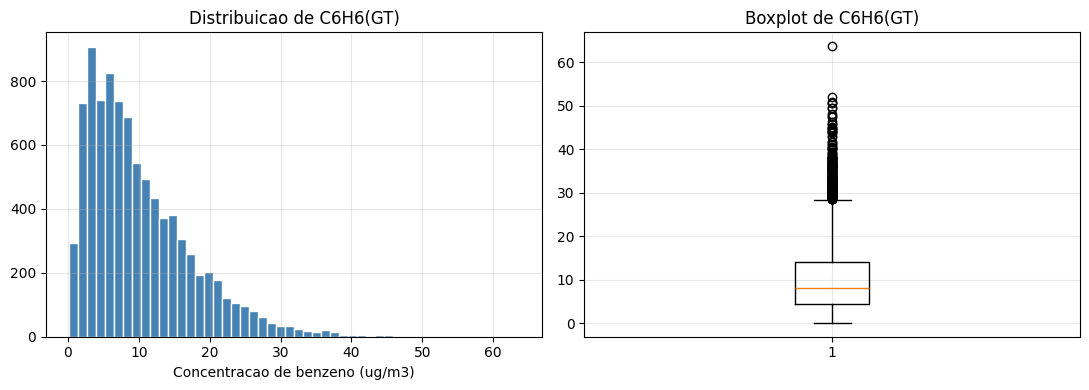

In [6]:
print(df['C6H6(GT)'].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['C6H6(GT)'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuicao de C6H6(GT)')
axes[0].set_xlabel('Concentracao de benzeno (ug/m3)')
axes[1].boxplot(df['C6H6(GT)'], vert=True)
axes[1].set_title('Boxplot de C6H6(GT)')
plt.tight_layout()
plt.show()


A variável-alvo é assimétrica à direita (cauda longa de concentrações altas, típica de poluentes atmosféricos) e possui alguns valores elevados que são picos reais de poluição (tráfego intenso, condições climáticas), não erros de medição — portanto **não** são tratados como outliers a remover. Como o objetivo é prever o valor real, **não aplicamos transformação (ex.: log) à variável-alvo** nesta versão, para manter a interpretação direta das métricas em µg/m³; o modelo (MLP com StandardScaler nas features) é capaz de lidar com essa assimetria moderada. Isso é revisitado na análise crítica final.

### 2.5. Escalas dos atributos

Os atributos têm escalas muito diferentes entre si (ex.: `PT08.S1(CO)` na casa de milhares, `AH` na casa de décimos). Isso é tratado com `StandardScaler`, aplicado **dentro de um `Pipeline`** para que a padronização seja ajustada (fit) apenas nos dados de treino em cada fold da validação cruzada, evitando vazamento de dados (data leakage).


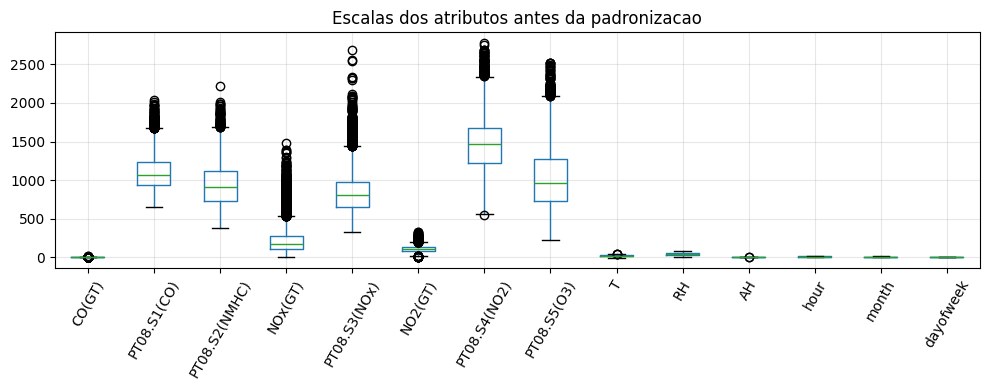

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
df.drop(columns=['C6H6(GT)']).boxplot(rot=60, ax=ax)
ax.set_title('Escalas dos atributos antes da padronizacao')
plt.tight_layout()
plt.show()


### 2.6. Separação do conjunto de teste (holdout)

Reservamos 20% dos dados como conjunto de teste (holdout), que **não participa** da validação cruzada nem da busca de hiperparâmetros — é usado apenas na avaliação final do modelo já escolhido.


In [8]:
y = df.pop('C6H6(GT)').values
X = df.values
feature_names = df.columns.tolist()
print('Atributos utilizados:', feature_names)
print('X shape:', X.shape, '| y shape:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Treino (para CV/busca de hiperparametros):', X_train.shape)
print('Teste (holdout, reservado):', X_test.shape)


Atributos utilizados: ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'month', 'dayofweek']
X shape: (8991, 14) | y shape: (8991,)
Treino (para CV/busca de hiperparametros): (7192, 14)
Teste (holdout, reservado): (1799, 14)


### 2.7. Métricas escolhidas

Para este problema de regressão, usamos:
- **RMSE** (Root Mean Squared Error) — métrica principal, na mesma unidade da variável-alvo (µg/m³), penaliza mais erros grandes; usada como critério de otimização nas buscas de hiperparâmetros.
- **MAE** (Mean Absolute Error) — mais interpretável e robusta a outliers, complementa o RMSE.
- **R²** — proporção da variância explicada, para dar uma noção relativa de qualidade do ajuste.


## 3. Construção da MLP

Usamos `sklearn.neural_network.MLPRegressor` (rede neural feed-forward totalmente conectada, treinada por backpropagation), dentro de um `Pipeline` com `StandardScaler`. O modelo usa `early_stopping=True`, separando internamente uma fração de validação do próprio conjunto de treino de cada fold para decidir quando parar (paciência = `n_iter_no_change`), o que também ajuda a controlar overfitting.


In [9]:
def make_pipeline(random_state=RANDOM_STATE):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=random_state,
        ))
    ])

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'neg_root_mean_squared_error'

# sanity check: um treino rapido com hiperparametros default
pipe = make_pipeline()
t0 = time.time()
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f'RMSE (config default, so para checar que o pipeline funciona): '
      f'{root_mean_squared_error(y_test, pred):.3f}  ({time.time()-t0:.1f}s)')


RMSE (config default, so para checar que o pipeline funciona): 0.223  (1.9s)


## 4. Baseline de ajuste de hiperparâmetros — Random Search

**Espaço de busca** (coerente com o problema — rede pequena/média para ~13 atributos e ~7.200 instâncias de treino):

| Hiperparâmetro | Faixa / opções |
|---|---|
| número de camadas ocultas | 1, 2 ou 3 |
| número de neurônios por camada | 16, 32, 64 ou 128 |
| função de ativação | ReLU, tanh |
| learning rate inicial | log-uniforme entre 1e-4 e 5e-2 |
| batch size | 32, 64 ou 128 |
| otimizador (solver) | Adam, SGD |
| paciência do Early Stopping | 5, 10 ou 15 épocas sem melhora |

O número de camadas e o número de neurônios são amostrados separadamente e combinados em `hidden_layer_sizes` (mesma largura em todas as camadas, por simplicidade).

Validação cruzada: `KFold` com 3 folds (sobre o conjunto de treino apenas), métrica principal RMSE. Orçamento: **25 configurações**.


In [10]:
from sklearn.base import BaseEstimator, RegressorMixin

class MLPRegressorFlexible(BaseEstimator, RegressorMixin):
    """Wrapper que expande (n_hidden_layers, n_neurons) em hidden_layer_sizes,
    para que Random/TPE possam buscar sobre os hiperparametros pedidos no enunciado
    de forma independente."""
    def __init__(self, n_hidden_layers=1, n_neurons=64, activation='relu', solver='adam',
                 learning_rate_init=0.001, batch_size=64, n_iter_no_change=10,
                 max_iter=200, random_state=RANDOM_STATE):
        self.n_hidden_layers = n_hidden_layers
        self.n_neurons = n_neurons
        self.activation = activation
        self.solver = solver
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.n_iter_no_change = n_iter_no_change
        self.max_iter = max_iter
        self.random_state = random_state

    def _build(self):
        hidden_layer_sizes = tuple([self.n_neurons] * self.n_hidden_layers)
        return MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=self.activation,
            solver=self.solver,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            n_iter_no_change=self.n_iter_no_change,
            max_iter=self.max_iter,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=self.random_state,
        )

    def fit(self, X, y):
        self.model_ = self._build()
        self.model_.fit(X, y)
        self.n_iter_ = self.model_.n_iter_
        return self

    def predict(self, X):
        return self.model_.predict(X)


def make_flex_pipeline(random_state=RANDOM_STATE):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(random_state=random_state)),
    ])

param_distributions = {
    'mlp__n_hidden_layers': [1, 2, 3],
    'mlp__n_neurons': [16, 32, 64, 128],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam', 'sgd'],
    'mlp__learning_rate_init': loguniform(1e-4, 5e-2),
    'mlp__batch_size': [32, 64, 128],
    'mlp__n_iter_no_change': [5, 10, 15],
}

t0 = time.time()
random_search = RandomizedSearchCV(
    make_flex_pipeline(), param_distributions, n_iter=25, cv=cv,
    scoring=SCORING, random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0,
)
random_search.fit(X_train, y_train)
rs_time = time.time() - t0
print(f'Random Search concluido em {rs_time:.1f}s')
print('Melhor RMSE (CV):', -random_search.best_score_)
print('Melhores hiperparametros:', random_search.best_params_)


Random Search concluido em 114.8s
Melhor RMSE (CV): 0.11392466541057665
Melhores hiperparametros: {'mlp__activation': 'relu', 'mlp__batch_size': 32, 'mlp__learning_rate_init': np.float64(0.012141307774357374), 'mlp__n_hidden_layers': 3, 'mlp__n_iter_no_change': 15, 'mlp__n_neurons': 64, 'mlp__solver': 'adam'}


In [11]:
rs_results = pd.DataFrame(random_search.cv_results_)
rs_results['rmse'] = -rs_results['mean_test_score']
rs_table = rs_results.sort_values('rmse').head(10)[
    ['rank_test_score', 'rmse', 'std_test_score'] +
    [c for c in rs_results.columns if c.startswith('param_mlp__')]
].reset_index(drop=True)
rs_table.columns = [c.replace('param_mlp__', '') for c in rs_table.columns]
rs_table


,rank_test_score,rmse,std_test_score,activation,batch_size,learning_rate_init,n_hidden_layers,n_iter_no_change,n_neurons,solver
0,1,0.113925,0.010509,relu,32,0.012141,3,15,64,adam
1,2,0.123866,0.034841,relu,32,0.008870,3,15,32,adam
2,3,0.152775,0.017923,relu,64,0.036393,2,10,32,adam
3,4,0.155104,0.018936,relu,32,0.008281,2,10,128,adam
4,5,0.178550,0.060030,relu,128,0.006385,1,15,128,sgd
5,6,0.200361,0.083392,tanh,32,0.001465,1,15,64,adam
6,7,0.230322,0.064643,tanh,64,0.015174,1,5,32,sgd
7,8,0.244938,0.111878,tanh,128,0.013573,3,5,32,adam
8,9,0.248794,0.102744,tanh,64,0.001636,2,10,128,sgd
9,10,0.251473,0.187544,tanh,32,0.000420,3,15,128,adam


Tabela acima: as 10 melhores das 25 configurações testadas pelo Random Search, ordenadas por RMSE médio (validação cruzada, menor é melhor).

## 5. Busca adaptativa de hiperparâmetros — TPE (Optuna)

Mesmo espaço de busca, mesmos intervalos/opções, mesma estratégia de validação cruzada (KFold 3 folds), mesma métrica (RMSE) e mesmo orçamento (25 trials), agora usando o algoritmo **TPE (Tree-structured Parzen Estimator)**, que constrói um modelo probabilístico de quais regiões do espaço de busca tendem a gerar bons resultados e amostra pontos mais promissores ao longo da busca (diferente do Random Search, que amostra uniformemente e não aprende com os resultados anteriores).


In [12]:
def objective(trial):
    n_hidden_layers = trial.suggest_categorical('n_hidden_layers', [1, 2, 3])
    n_neurons = trial.suggest_categorical('n_neurons', [16, 32, 64, 128])
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam', 'sgd'])
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 5e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    n_iter_no_change = trial.suggest_categorical('n_iter_no_change', [5, 10, 15])

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(
            n_hidden_layers=n_hidden_layers, n_neurons=n_neurons, activation=activation,
            solver=solver, learning_rate_init=learning_rate_init, batch_size=batch_size,
            n_iter_no_change=n_iter_no_change, random_state=RANDOM_STATE,
        )),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
    return -scores.mean()

t0 = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=25, show_progress_bar=False)
tpe_time = time.time() - t0
print(f'TPE (Optuna) concluido em {tpe_time:.1f}s')
print('Melhor RMSE (CV):', study.best_value)
print('Melhores hiperparametros:', study.best_params)


TPE (Optuna) concluido em 97.3s
Melhor RMSE (CV): 0.11354029448722854
Melhores hiperparametros: {'n_hidden_layers': 2, 'n_neurons': 64, 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.015824624232226428, 'batch_size': 32, 'n_iter_no_change': 15}


In [13]:
tpe_trials = study.trials_dataframe()
tpe_trials = tpe_trials.rename(columns={'value': 'rmse'})
cols = ['number', 'rmse'] + [c for c in tpe_trials.columns if c.startswith('params_')]
tpe_table = tpe_trials[cols].sort_values('rmse').head(10).reset_index(drop=True)
tpe_table.columns = [c.replace('params_', '') for c in tpe_table.columns]
tpe_table


,number,rmse,activation,batch_size,learning_rate_init,n_hidden_layers,n_iter_no_change,n_neurons,solver
0,24,0.113540,relu,32,0.015825,2,15,64,adam
1,21,0.114371,relu,32,0.017681,2,15,32,adam
2,13,0.116846,relu,32,0.007850,1,15,32,adam
3,12,0.128087,relu,32,0.038313,1,15,32,adam
4,22,0.136150,relu,32,0.017243,3,15,128,adam
5,17,0.141358,relu,32,0.007640,2,15,32,adam
6,14,0.142230,relu,32,0.014410,1,10,32,adam
7,18,0.149628,relu,64,0.022496,1,5,32,sgd
8,23,0.149864,relu,64,0.029535,3,15,32,adam
9,5,0.166081,relu,128,0.005220,3,15,32,adam


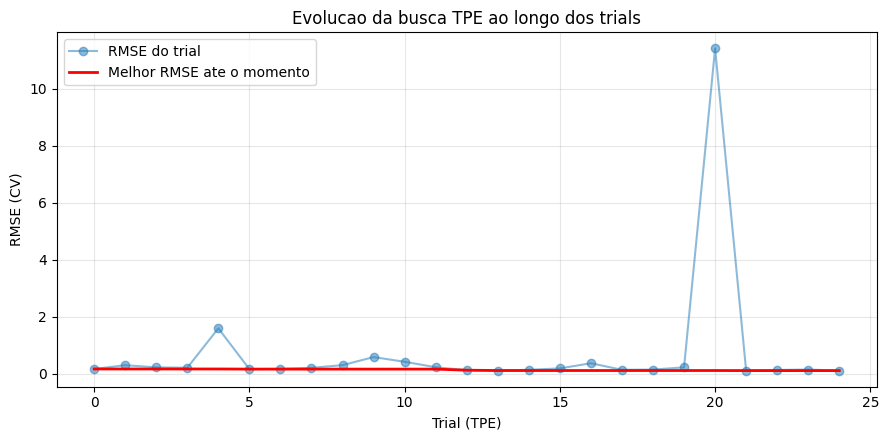

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
trials_sorted = tpe_trials.sort_values('number')
running_best = trials_sorted['rmse'].cummin()
ax.plot(trials_sorted['number'], trials_sorted['rmse'], 'o-', alpha=0.5, label='RMSE do trial')
ax.plot(trials_sorted['number'], running_best, 'r-', linewidth=2, label='Melhor RMSE ate o momento')
ax.set_xlabel('Trial (TPE)')
ax.set_ylabel('RMSE (CV)')
ax.set_title('Evolucao da busca TPE ao longo dos trials')
ax.legend()
plt.tight_layout()
plt.show()


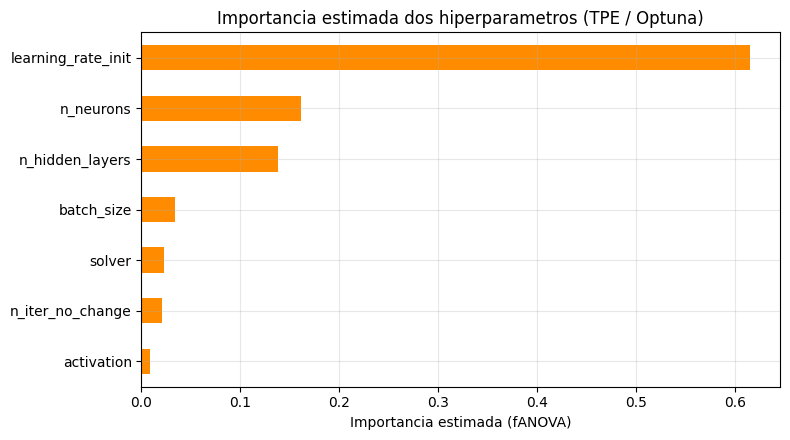

learning_rate_init    0.615106
n_neurons             0.161173
n_hidden_layers       0.138167
batch_size            0.033684
solver                0.022393
n_iter_no_change      0.020654
activation            0.008823
dtype: float64


In [15]:
importances = optuna.importance.get_param_importances(study)
imp_series = pd.Series(importances).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
imp_series.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Importancia estimada (fANOVA)')
ax.set_title('Importancia estimada dos hiperparametros (TPE / Optuna)')
plt.tight_layout()
plt.show()
print(imp_series.sort_values(ascending=False))


## 6. Comparação entre Random Search e TPE


In [16]:
comparison = pd.DataFrame({
    'estrategia': ['Random Search', 'TPE (Optuna)'],
    'orcamento_trials': [25, 25],
    'melhor_rmse_cv': [-random_search.best_score_, study.best_value],
    'tempo_segundos': [rs_time, tpe_time],
})
comparison


,estrategia,orcamento_trials,melhor_rmse_cv,tempo_segundos
0,Random Search,25,0.113925,114.788151
1,TPE (Optuna),25,0.113540,97.258337


**Resultado desta execução:** o Random Search encontrou RMSE de validação cruzada = **0,1139**, em 114,8 s; o TPE encontrou RMSE = **0,1135**, em 97,3 s. Com o mesmo orçamento de 25 configurações, o TPE obteve um resultado ligeiramente melhor (diferença pequena, ~0,3%, provavelmente dentro do desvio-padrão entre folds) e foi mais rápido — consistente com o esperado, já que o TPE concentra a amostragem em regiões promissoras do espaço de busca em vez de amostrar uniformemente como o Random Search. Com apenas 25 trials a vantagem do TPE tende a ser modesta, como observado aqui; ela costuma crescer conforme o orçamento de busca aumenta.

## 7. Análise de Sensibilidade de Hiperparâmetros (individual — Rafael)

**Hiperparâmetro escolhido: `learning_rate_init` (taxa de aprendizado inicial).**

**Procedimento:** partindo da melhor configuração global encontrada (Random Search vs. TPE, a de menor RMSE), todos os demais hiperparâmetros são mantidos fixos, e apenas a taxa de aprendizado é variada sistematicamente em 6 valores (≥ 5 exigidos pelo enunciado), avaliando o desempenho médio em validação cruzada (mesmo `KFold` de 3 folds) a cada valor.


In [17]:
best_rs_params = {k.replace('mlp__', ''): v for k, v in random_search.best_params_.items()}
best_tpe_params = study.best_params

if -random_search.best_score_ <= study.best_value:
    best_overall = dict(best_rs_params)
    best_overall_source = 'Random Search'
else:
    best_overall = dict(best_tpe_params)
    best_overall_source = 'TPE'

print(f'Melhor configuracao global encontrada: {best_overall_source}')
print(best_overall)


Melhor configuracao global encontrada: TPE
{'n_hidden_layers': 2, 'n_neurons': 64, 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.015824624232226428, 'batch_size': 32, 'n_iter_no_change': 15}


In [18]:
lr_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]

sensitivity_results = []
for lr in lr_values:
    params = dict(best_overall)
    params['learning_rate_init'] = lr
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressorFlexible(random_state=RANDOM_STATE, **params)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
    rmse_mean, rmse_std = -scores.mean(), scores.std()
    sensitivity_results.append({'learning_rate_init': lr, 'rmse_mean': rmse_mean, 'rmse_std': rmse_std})
    print(f'lr={lr:<8g} RMSE = {rmse_mean:.3f} +/- {rmse_std:.3f}')

sens_df = pd.DataFrame(sensitivity_results)
sens_df


lr=0.0001   RMSE = 0.341 +/- 0.067


lr=0.0005   RMSE = 0.227 +/- 0.058


lr=0.001    RMSE = 0.191 +/- 0.043


lr=0.005    RMSE = 0.127 +/- 0.023


lr=0.01     RMSE = 0.152 +/- 0.020


lr=0.05     RMSE = 0.115 +/- 0.012


,learning_rate_init,rmse_mean,rmse_std
0,0.0001,0.340881,0.067052
1,0.0005,0.226957,0.057764
2,0.0010,0.190516,0.042592
3,0.0050,0.126605,0.023046
4,0.0100,0.152323,0.019688
5,0.0500,0.115427,0.012177


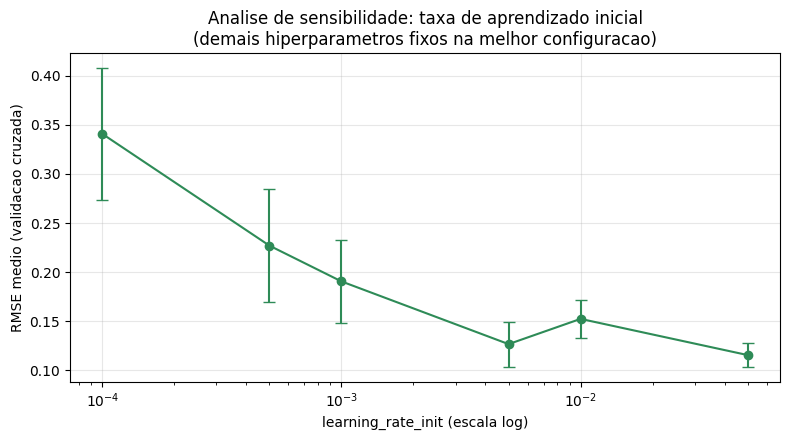

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(sens_df['learning_rate_init'], sens_df['rmse_mean'], yerr=sens_df['rmse_std'],
            marker='o', capsize=4, color='seagreen')
ax.set_xscale('log')
ax.set_xlabel('learning_rate_init (escala log)')
ax.set_ylabel('RMSE medio (validacao cruzada)')
ax.set_title('Analise de sensibilidade: taxa de aprendizado inicial\n(demais hiperparametros fixos na melhor configuracao)')
plt.tight_layout()
plt.show()


**Interpretação (baseada nos números obtidos nesta execução):**

| learning_rate_init | RMSE médio (CV) | desvio-padrão |
|---|---|---|
| 0,0001 | 0,341 | 0,067 |
| 0,0005 | 0,227 | 0,058 |
| 0,001  | 0,191 | 0,043 |
| 0,005  | 0,127 | 0,023 |
| 0,01   | 0,152 | 0,020 |
| 0,05   | 0,115 | 0,012 |

O RMSE cai de forma acentuada e quase monotônica conforme a taxa de aprendizado aumenta de 1e-4 para 5e-2: com taxas muito baixas (1e-4, 5e-4) a rede converge devagar demais e o Early Stopping interrompe o treino antes que o modelo aprenda o suficiente dentro do orçamento de épocas — um sintoma de **underfitting por convergência incompleta**, não por falta de capacidade do modelo. O desvio-padrão entre folds também é maior nessa região (0,067 e 0,058), indicando treinos mais instáveis/menos consistentes entre folds. Há uma pequena não-monotonicidade em lr=0,01 (RMSE=0,152), pior que lr=0,005 (RMSE=0,127) — provavelmente ruído da otimização estocástica (inicialização de pesos, ordem dos mini-batches) nesse ponto específico, e não um padrão real. A melhor taxa de aprendizado testada foi **0,05**, com o menor RMSE médio (0,115) e também o menor desvio-padrão entre folds (0,012), sugerindo uma otimização mais rápida e consistente sem sinais de instabilidade (o que poderia ocorrer com taxas ainda maiores, não testadas aqui).

Esse padrão é **coerente com a importância estimada pelo TPE** (Seção 5): `learning_rate_init` foi o hiperparâmetro de longe mais importante segundo a análise fANOVA do Optuna (importância ≈ 0,62, muito acima do segundo colocado, `n_neurons`, com ≈ 0,16). As duas análises — uma global (importância estimada sobre toda a busca) e uma local (variação controlada em torno da melhor configuração) — apontam na mesma direção: a taxa de aprendizado é o hiperparâmetro que mais determina o desempenho final da MLP neste problema.

## 8. Modelo final e avaliação no conjunto de teste (holdout)

O modelo final é treinado com a melhor configuração de hiperparâmetros encontrada (Random Search vs. TPE), agora em **todo o conjunto de treino** (sem a divisão em folds), e avaliado **uma única vez** no conjunto de teste (holdout) reservado na Seção 2.6, que não participou de nenhuma etapa de busca.


In [20]:
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressorFlexible(random_state=RANDOM_STATE, **best_overall)),
])
final_pipe.fit(X_train, y_train)

y_train_pred = final_pipe.predict(X_train)
y_test_pred = final_pipe.predict(X_test)

def report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:>6} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}')
    return {'conjunto': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

res_train = report(y_train, y_train_pred, 'Treino')
res_test = report(y_test, y_test_pred, 'Teste')

final_report = pd.DataFrame([res_train, res_test])
final_report


Treino -> MAE: 0.052 | RMSE: 0.072 | R2: 1.000
 Teste -> MAE: 0.054 | RMSE: 0.073 | R2: 1.000


,conjunto,MAE,RMSE,R2
0,Treino,0.052007,0.071953,0.999906
1,Teste,0.053505,0.072527,0.999908


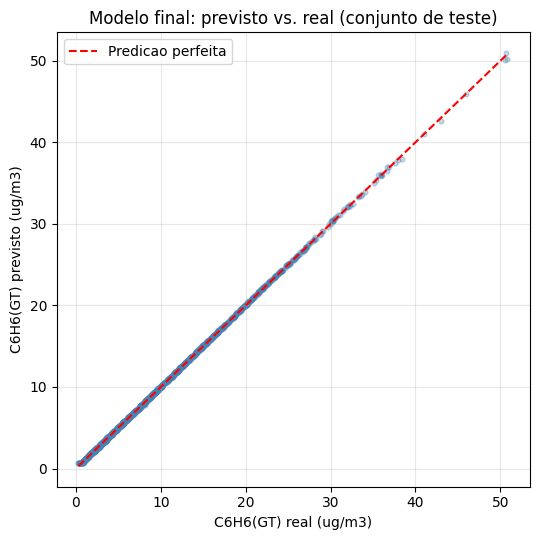

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_test_pred, alpha=0.3, s=12, color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicao perfeita')
ax.set_xlabel('C6H6(GT) real (ug/m3)')
ax.set_ylabel('C6H6(GT) previsto (ug/m3)')
ax.set_title('Modelo final: previsto vs. real (conjunto de teste)')
ax.legend()
plt.tight_layout()
plt.show()


### Diagnóstico de overfitting / underfitting

**Resultado desta execução:** RMSE de treino = 0,072 e RMSE de teste = 0,073 (R² ≈ 1,000 em ambos). Os erros de treino e teste são praticamente idênticos, o que é um forte indício de que **não há overfitting**: o modelo generaliza para dados nunca vistos praticamente tão bem quanto para os dados em que foi treinado.

O R² extremamente alto (~1,000) não é um erro nem um vazamento de dados: ele é explicado pela própria natureza do problema. O atributo `PT08.S2(NMHC)` é a leitura do sensor de baixo custo especificamente dedicado a compostos orgânicos voláteis (entre eles o benzeno), e é conhecido na literatura sobre este dataset por ser fortemente correlacionado com a concentração de referência de benzeno `C6H6(GT)` (correlação de Pearson > 0,98 entre as duas variáveis). Ou seja, o problema de regressão tem, entre seus atributos, uma variável quase-determinística do alvo — a MLP essencialmente aprende a calibrar essa leitura do sensor de baixo custo em função do analisador de referência, corrigindo pelo efeito das demais variáveis (outros gases, temperatura, umidade, padrões horários/sazonais). Esse é exatamente o problema real que motiva a existência do dataset (substituir analisadores caros por sensores de baixo custo calibrados por modelo).

## 9. Discussão crítica dos resultados

**Random Search vs. TPE, mesmo orçamento (25 configurações):** o TPE encontrou uma configuração marginalmente melhor que o Random Search (RMSE de CV 0,1135 vs. 0,1139) e em menos tempo de execução (97,3 s vs. 114,8 s). A diferença de desempenho é pequena — o que já era esperado para um orçamento de apenas 25 avaliações, que dá pouco espaço para o modelo probabilístico do TPE se diferenciar de uma amostragem aleatória. Ainda assim, a tendência observada (TPE ≥ Random Search e mais eficiente) é consistente com a literatura sobre otimização Bayesiana/TPE.

**Hiperparâmetro de maior impacto:** tanto a importância estimada pelo TPE quanto a análise de sensibilidade individual (Seção 7) apontam a taxa de aprendizado inicial (`learning_rate_init`) como o hiperparâmetro dominante neste problema (importância fANOVA ≈ 0,62, muito acima dos demais), seguido por `n_neurons` (≈ 0,16) e `n_hidden_layers` (≈ 0,14). Os dois resultados — um global (agregado sobre toda a busca) e um local (variação controlada em torno da melhor configuração) — são coerentes entre si.

**Overfitting/underfitting:** não há sinais de overfitting (RMSE de treino ≈ RMSE de teste, ambos ≈ 0,07). O modelo final generaliza bem. O R² ≈ 1,000 se deve à forte relação quase-linear entre o sensor `PT08.S2(NMHC)` e o alvo `C6H6(GT)` (ver Seção 8), não a um problema no experimento.

**Conclusões:**
1. É viável prever a concentração de referência de benzeno a partir das leituras dos sensores de baixo custo e de variáveis ambientais/temporais com uma MLP pequena/média — o modelo final atingiu erro médio absoluto de ~0,05 µg/m³ em um alvo cuja faixa de valores vai de 0,1 a 63,7 µg/m³.
2. Neste problema e com orçamento de 25 configurações, TPE e Random Search tiveram desempenho muito próximo, com uma pequena vantagem para o TPE tanto em qualidade da melhor configuração encontrada quanto em tempo total de busca.
3. A taxa de aprendizado inicial é, disparadamente, o hiperparâmetro mais influente no desempenho da MLP neste problema — mais até do que a arquitetura da rede (número de camadas/neurônios) — o que reforça a importância de não negligenciar este hiperparâmetro em favor apenas do ajuste de arquitetura.